In [17]:
# IMPORTS

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.nn import functional as F
import json
import os
from CNN import SymbolClassifierCNN
from sklearn.metrics import confusion_matrix

In [18]:
# DATA LOADING & INITIALIZATION

# Load label map to determine num_classes
label_map_path = os.path.join("datasets", "label_map.json")
if os.path.isfile(label_map_path):
    with open(label_map_path, "r") as f:
        label_map = json.load(f)
    num_classes = len(label_map)
    print(f"Loaded label_map with {num_classes} classes: {list(label_map.keys())}")
else:
    raise FileNotFoundError(f"label_map.json not found at {label_map_path}")

# Load datasets
X_train = torch.from_numpy(np.load(os.path.join("datasets", "X_train.npy"))).float()
Y_train = torch.from_numpy(np.load(os.path.join("datasets", "Y_train.npy"))).long()
X_eval = torch.from_numpy(np.load(os.path.join("datasets", "X_eval.npy"))).float()
Y_eval = torch.from_numpy(np.load(os.path.join("datasets", "Y_eval.npy"))).long()

print(f"Train: X {X_train.shape}, Y {Y_train.shape}")
print(f"Eval: X {X_eval.shape}, Y {Y_eval.shape}")

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

eval_dataset = TensorDataset(X_eval, Y_eval)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

# Initialize model
model = SymbolClassifierCNN(num_classes=num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

Loaded label_map with 16 classes: ['eight', 'decimal', 'div', 'minus', 'nine', 'times', 'three', 'one', 'zero', 'seven', 'two', 'equal', 'six', 'five', 'plus', 'four']
Train: X torch.Size([7557, 1, 150, 135]), Y torch.Size([7557])
Eval: X torch.Size([1010, 1, 150, 135]), Y torch.Size([1010])
Using device: cpu


In [19]:
# TRAINING LOOP

def compute_accuracy(outputs, labels):
    """Compute accuracy from model outputs and labels."""
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

def augment_batch(x):
    """Light on-the-fly augments to improve generalization."""
    # x: (B, 1, H, W)
    if torch.rand(1) < 0.5:
        x = torch.flip(x, dims=[3])  # horizontal flip
    if torch.rand(1) < 0.3:
        x = torch.flip(x, dims=[2])  # vertical flip
    if torch.rand(1) < 0.5:
        noise = torch.randn_like(x) * 0.03
        x = torch.clamp(x + noise, 0.0, 1.0)
    return x

# Training configuration
num_epochs = 50
patience = 5  # Early stopping patience
best_eval_loss = float("inf")
patience_counter = 0

# Tracking metrics
training_loss = []
training_acc = []
evaluation_loss = []
evaluation_acc = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    num_batches = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = augment_batch(inputs)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_acc += compute_accuracy(outputs, labels)
        num_batches += 1

    avg_train_loss = total_train_loss / num_batches
    avg_train_acc = total_train_acc / num_batches
    training_loss.append(avg_train_loss)
    training_acc.append(avg_train_acc)

    # Evaluation phase
    model.eval()
    total_eval_loss = 0
    total_eval_acc = 0
    num_batches = 0

    with torch.no_grad():
        for inputs, labels in eval_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_eval_loss += loss.item()
            total_eval_acc += compute_accuracy(outputs, labels)
            num_batches += 1

    avg_eval_loss = total_eval_loss / num_batches
    avg_eval_acc = total_eval_acc / num_batches
    evaluation_loss.append(avg_eval_loss)
    evaluation_acc.append(avg_eval_acc)

    scheduler.step(avg_eval_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f} | "
        f"Eval Loss: {avg_eval_loss:.4f}, Acc: {avg_eval_acc:.4f}"
    )

    # Early stopping
    if avg_eval_loss < best_eval_loss:
        best_eval_loss = avg_eval_loss
        patience_counter = 0
        torch.save(model.state_dict(), "symbol_classifier_best.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(
                f"\nEarly stopping triggered after {epoch + 1} epochs "
                f"(no improvement for {patience} epochs)"
            )
            break

Epoch 1/50 | Train Loss: 1.6868, Acc: 0.4564 | Eval Loss: 0.8928, Acc: 0.7152
Epoch 2/50 | Train Loss: 0.8181, Acc: 0.7398 | Eval Loss: 0.6224, Acc: 0.7943
Epoch 3/50 | Train Loss: 0.5861, Acc: 0.8099 | Eval Loss: 0.5010, Acc: 0.8408
Epoch 4/50 | Train Loss: 0.4960, Acc: 0.8413 | Eval Loss: 0.4244, Acc: 0.8576
Epoch 5/50 | Train Loss: 0.4299, Acc: 0.8586 | Eval Loss: 0.4528, Acc: 0.8480
Epoch 6/50 | Train Loss: 0.3758, Acc: 0.8809 | Eval Loss: 0.3613, Acc: 0.8711
Epoch 7/50 | Train Loss: 0.3289, Acc: 0.8938 | Eval Loss: 0.3871, Acc: 0.8750
Epoch 8/50 | Train Loss: 0.2951, Acc: 0.9037 | Eval Loss: 0.3269, Acc: 0.8955
Epoch 9/50 | Train Loss: 0.2724, Acc: 0.9144 | Eval Loss: 0.3204, Acc: 0.9057
Epoch 10/50 | Train Loss: 0.2469, Acc: 0.9222 | Eval Loss: 0.2910, Acc: 0.9111
Epoch 11/50 | Train Loss: 0.2259, Acc: 0.9289 | Eval Loss: 0.2915, Acc: 0.9055
Epoch 12/50 | Train Loss: 0.2176, Acc: 0.9273 | Eval Loss: 0.2781, Acc: 0.9055
Epoch 13/50 | Train Loss: 0.2026, Acc: 0.9324 | Eval Loss: 0.

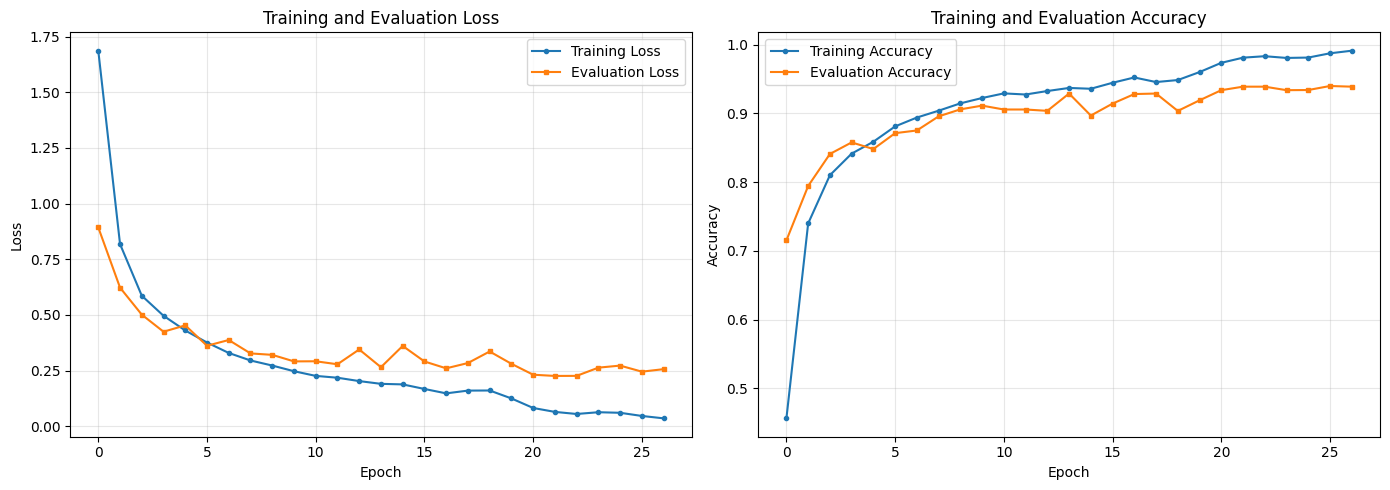


Final Results:
Best Training Accuracy: 0.9910
Best Evaluation Accuracy: 0.9397
Final Eval Loss: 0.2561


In [20]:
# PLOT RESULTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(training_loss, label="Training Loss", marker='o', markersize=3)
ax1.plot(evaluation_loss, label="Evaluation Loss", marker='s', markersize=3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Evaluation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(training_acc, label="Training Accuracy", marker='o', markersize=3)
ax2.plot(evaluation_acc, label="Evaluation Accuracy", marker='s', markersize=3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Evaluation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Best Training Accuracy: {max(training_acc):.4f}")
print(f"Best Evaluation Accuracy: {max(evaluation_acc):.4f}")
print(f"Final Eval Loss: {evaluation_loss[-1]:.4f}")

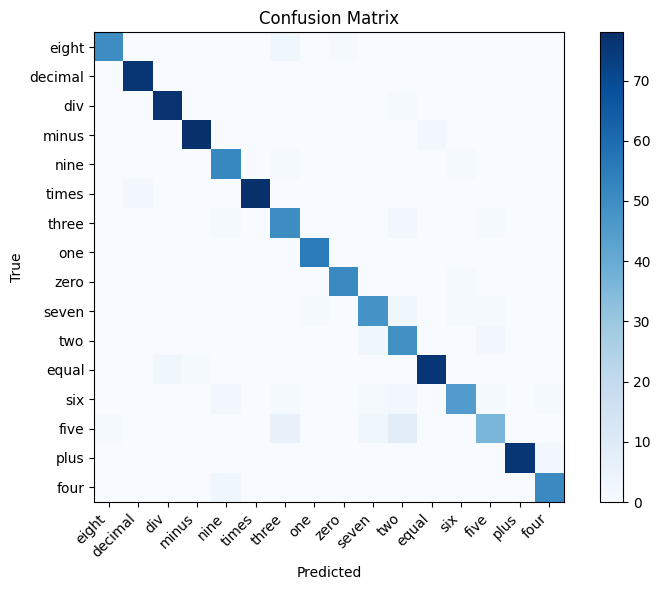

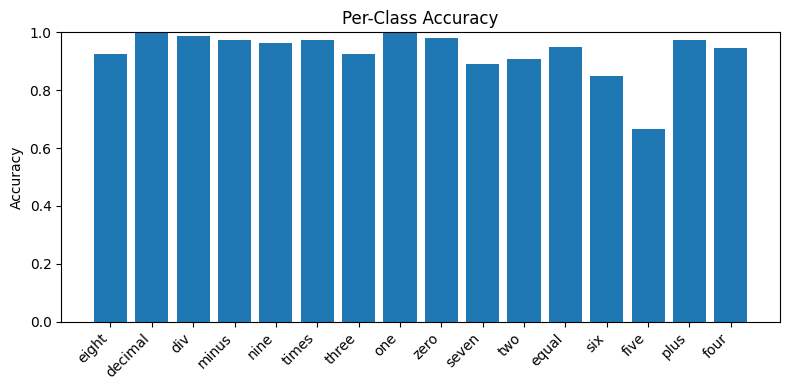

In [21]:
# Collect predictions
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(list(label_map.keys()), rotation=45, ha="right")
ax.set_yticklabels(list(label_map.keys()))
plt.tight_layout()
plt.show()

# Per-class accuracy
per_class_acc = (cm.diagonal() / cm.sum(axis=1).clip(min=1))
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(list(label_map.keys()), per_class_acc)
ax.set_ylim(0,1)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
# SAVE FINAL TRAINED MODEL

torch.save(model.state_dict(), "symbol_classifier.pth")